# Main-report predictive figures

This notebook regenerates the two main-report predictive figures from cached `01_mfa.ipynb` handoff artifacts:

- Figure 1: leave-one-dataset-out MAE
- Figure 2: leave-one-dataset-out sign accuracy

Set `PREDICTIVE_ESTIMATORS` to choose the predictive model used for the non-baseline variants. The paper default is `ridge`; `tree` and `xgboost` are nonlinear sensitivity checks.

In [7]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
except Exception:  # pragma: no cover - notebook convenience
    XGBRegressor = None

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})

## Settings

Edit this cell when you want to compare Ridge, decision tree, or XGBoost. If you set several estimators, the notebook writes one MAE/sign-accuracy pair per estimator.

In [8]:
cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    package_dir = cwd.parent
    repo_dir = package_dir.parent
elif cwd.name == "meta-feature-analysis":
    package_dir = cwd
    repo_dir = cwd.parent
else:
    repo_dir = cwd
    package_dir = repo_dir / "meta-feature-analysis"

handoff_root = package_dir / ".mfa_cache" / "notebook_handoff"
paper_figure_dir = repo_dir / "icml2026" / "figures"
paper_figure_dir.mkdir(parents=True, exist_ok=True)

# Main-report comparisons in display order.
MAIN_COMPARISONS = [
    {
        "label": "Standard vs. foundation",
        "config_dir": "config_1_c4472762a9293af4",
    },
    {
        "label": "TabICL v2 vs TabPFN v2.6",
        "config_dir": "config_2_781b7f9c27428458",
    },
    {
        "label": "NN vs. tree",
        "config_dir": "config_0_f025f9bfe1d83684",
    },
]

# Paper default: use the general matrix. Set to "analysis_classification_reduced" for the classification appendix.
ANALYSIS_TABLE = "analysis_general_reduced"

# Choose one or several: "ridge", "tree", "xgboost".
PREDICTIVE_ESTIMATORS = ["ridge"]

# Predictor variants to show in each figure.
PREDICTOR_SETS = [
    "mean_baseline",
    "controls",
    "meta_features",
    "controls_plus_meta",
]

# If True, ridge/general writes the exact filenames used by the paper.
WRITE_PAPER_FILENAMES_FOR_RIDGE = True
EXPORT_FORMATS = ["pdf", "png"]
BOOTSTRAP_SAMPLES = 5000

TARGET = "delta_norm"
UNIT_COLUMN = "dataset"
RANDOM_STATE = 20260424
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

GENERAL_CONTROLS = [
    "log_n",
    "log_d",
    "d_over_n",
    "cat_fraction",
    "feature_missing_fraction",
]
CLASSIFICATION_CONTROLS = ["n_classes", "class_imbalance_ratio"]

print(f"handoff_root: {handoff_root}")
print(f"paper_figure_dir: {paper_figure_dir}")

handoff_root: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/.mfa_cache/notebook_handoff
paper_figure_dir: /work/mherre/tabular-meta-feature-analysis/icml2026/figures


## Load cached analysis matrices

In [9]:
def load_analysis_table(config_dir: str, table_name: str) -> pd.DataFrame:
    path = handoff_root / config_dir / f"{table_name}.pkl"
    if not path.exists():
        raise FileNotFoundError(f"Missing handoff artifact: {path}")
    frame = pd.read_pickle(path).copy()
    if TARGET not in frame.columns:
        raise KeyError(f"{path} does not contain target column {TARGET!r}")
    if UNIT_COLUMN not in frame.columns:
        raise KeyError(f"{path} does not contain unit column {UNIT_COLUMN!r}")
    return frame


analysis_tables = {}
for spec in MAIN_COMPARISONS:
    analysis_tables[spec["label"]] = load_analysis_table(
        spec["config_dir"], ANALYSIS_TABLE
    )

pd.DataFrame(
    {
        "comparison": label,
        "rows": len(frame),
        "datasets": frame[UNIT_COLUMN].nunique(),
        "columns": frame.shape[1],
    }
    for label, frame in analysis_tables.items()
)

,comparison,rows,datasets,columns
0,Standard vs. foundation,51,51,302
1,TabICL v2 vs TabPFN v2.6,51,51,302
2,NN vs. tree,51,51,301


## Leave-one-dataset-out evaluation

In [10]:
METADATA_COLUMNS = {
    UNIT_COLUMN,
    "task_type",
    "comparison_name",
    "group_a_name",
    "group_b_name",
    "group_a_label",
    "group_b_label",
    "expected_direction",
    "n_splits",
    "best_a_error",
    "best_a_norm_error",
    "best_b_error",
    "best_b_norm_error",
    "delta_raw",
    "delta_raw_std",
    "delta_raw_sem",
    "delta_norm",
    "delta_norm_std",
    "delta_norm_sem",
}

PREDICTOR_LABELS = {
    "mean_baseline": "Mean baseline",
    "controls": "Controls",
    "meta_features": "Meta-features",
    "controls_plus_meta": "Controls + meta-features",
}

ESTIMATOR_LABELS = {
    "ridge": "Ridge",
    "tree": "Decision tree",
    "xgboost": "XGBoost",
}


def controls_for_table(table_name: str, frame: pd.DataFrame) -> list[str]:
    controls = list(GENERAL_CONTROLS)
    if "classification" in table_name:
        controls += CLASSIFICATION_CONTROLS
    return [
        c
        for c in controls
        if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])
    ]


def meta_feature_columns(frame: pd.DataFrame, controls: list[str]) -> list[str]:
    excluded = METADATA_COLUMNS | set(controls)
    cols = []
    for col in frame.columns:
        if col in excluded:
            continue
        if not pd.api.types.is_numeric_dtype(frame[col]):
            continue
        if frame[col].notna().sum() < 2:
            continue
        if frame[col].nunique(dropna=True) < 2:
            continue
        cols.append(col)
    return cols


def estimator_pipeline(estimator_name: str):
    if estimator_name == "ridge":
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", RidgeCV(alphas=RIDGE_ALPHAS, cv=None)),
            ]
        )
    if estimator_name == "tree":
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    DecisionTreeRegressor(
                        max_depth=2,
                        min_samples_leaf=5,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    if estimator_name == "xgboost":
        if XGBRegressor is None:
            raise ImportError("xgboost is not installed in this environment")
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    XGBRegressor(
                        objective="reg:squarederror",
                        n_estimators=100,
                        max_depth=2,
                        learning_rate=0.05,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_lambda=10.0,
                        min_child_weight=5.0,
                        random_state=RANDOM_STATE,
                        n_jobs=1,
                    ),
                ),
            ]
        )
    raise ValueError(f"Unknown estimator_name={estimator_name!r}")


def predictor_columns(
    frame: pd.DataFrame, predictor_set: str, controls: list[str], meta_cols: list[str]
) -> list[str]:
    if predictor_set == "mean_baseline":
        return []
    if predictor_set == "controls":
        return controls
    if predictor_set == "meta_features":
        return meta_cols
    if predictor_set == "controls_plus_meta":
        return controls + meta_cols
    raise ValueError(f"Unknown predictor_set={predictor_set!r}")


def loodo_predictions(
    frame: pd.DataFrame, comparison: str, estimator_name: str, predictor_set: str
) -> pd.DataFrame:
    frame = frame.loc[frame[TARGET].notna()].reset_index(drop=True)
    controls = controls_for_table(ANALYSIS_TABLE, frame)
    meta_cols = meta_feature_columns(frame, controls)
    features = predictor_columns(frame, predictor_set, controls, meta_cols)
    rows = []

    for test_idx in range(len(frame)):
        train = frame.drop(index=test_idx)
        test = frame.iloc[[test_idx]]
        y_train = train[TARGET].astype(float).to_numpy()
        y_true = float(test[TARGET].iloc[0])

        if predictor_set == "mean_baseline":
            y_pred = float(np.mean(y_train))
        else:
            model = estimator_pipeline(estimator_name)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(train[features], y_train)
            y_pred = float(model.predict(test[features])[0])

        rows.append(
            {
                "comparison": comparison,
                "estimator": estimator_name,
                "predictor_set": predictor_set,
                "predictor_label": PREDICTOR_LABELS[predictor_set],
                "dataset": test[UNIT_COLUMN].iloc[0],
                "n_predictors": len(features),
                "y_true": y_true,
                "y_pred": y_pred,
                "absolute_error": abs(y_true - y_pred),
            }
        )
    return pd.DataFrame(rows)


def add_sign_accuracy(predictions: pd.DataFrame) -> pd.DataFrame:
    predictions = predictions.copy()
    true_sign = np.sign(predictions["y_true"])
    pred_sign = np.sign(predictions["y_pred"])
    predictions["sign_correct"] = (true_sign == pred_sign).astype(float)
    predictions.loc[true_sign == 0, "sign_correct"] = np.nan
    return predictions

In [11]:
all_predictions = []
for estimator_name in PREDICTIVE_ESTIMATORS:
    for comparison, frame in analysis_tables.items():
        for predictor_set in PREDICTOR_SETS:
            all_predictions.append(
                loodo_predictions(
                    frame=frame,
                    comparison=comparison,
                    estimator_name=estimator_name,
                    predictor_set=predictor_set,
                )
            )

predictions = add_sign_accuracy(pd.concat(all_predictions, ignore_index=True))


def bootstrap_mean_ci(
    values: pd.Series, *, n_bootstrap: int = BOOTSTRAP_SAMPLES
) -> tuple[float, float]:
    values = values.dropna().astype(float).to_numpy()
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(RANDOM_STATE)
    boot = rng.choice(values, size=(n_bootstrap, len(values)), replace=True).mean(
        axis=1
    )
    return tuple(np.quantile(boot, [0.025, 0.975]))


summary_rows = []
for keys, group in predictions.groupby(
    ["estimator", "comparison", "predictor_set", "predictor_label"], sort=False
):
    estimator, comparison, predictor_set, predictor_label = keys
    mae_low, mae_high = bootstrap_mean_ci(group["absolute_error"])
    sign_low, sign_high = bootstrap_mean_ci(group["sign_correct"])
    summary_rows.append(
        {
            "estimator": estimator,
            "comparison": comparison,
            "predictor_set": predictor_set,
            "predictor_label": predictor_label,
            "n": group["dataset"].count(),
            "n_predictors": int(group["n_predictors"].iloc[0]),
            "mae": group["absolute_error"].mean(),
            "mae_ci_low": mae_low,
            "mae_ci_high": mae_high,
            "sign_accuracy": group["sign_correct"].mean(),
            "sign_accuracy_ci_low": sign_low,
            "sign_accuracy_ci_high": sign_high,
        }
    )

summary = pd.DataFrame(summary_rows).sort_values(
    ["estimator", "comparison", "predictor_set"]
)
summary

,estimator,comparison,predictor_set,predictor_label,n,n_predictors,mae,mae_ci_low,mae_ci_high,sign_accuracy,sign_accuracy_ci_low,sign_accuracy_ci_high
9,ridge,NN vs. tree,controls,Controls,51,5,0.191549,0.151923,0.231164,0.549020,0.411765,0.686275
11,ridge,NN vs. tree,controls_plus_meta,Controls + meta-features,51,282,0.472447,0.173715,1.026734,0.607843,0.470588,0.745098
8,ridge,NN vs. tree,mean_baseline,Mean baseline,51,0,0.190860,0.151590,0.230670,0.549020,0.411765,0.686275
10,ridge,NN vs. tree,meta_features,Meta-features,51,277,0.476566,0.173085,1.040870,0.607843,0.470588,0.745098
1,ridge,Standard vs. foundation,controls,Controls,51,5,0.234119,0.185218,0.286497,0.784314,0.666667,0.882353
3,ridge,Standard vs. foundation,controls_plus_meta,Controls + meta-features,51,283,266.150301,0.225787,797.325707,0.764706,0.647059,0.882353
0,ridge,Standard vs. foundation,mean_baseline,Mean baseline,51,0,0.240973,0.192374,0.295878,0.784314,0.666667,0.882353
2,ridge,Standard vs. foundation,meta_features,Meta-features,51,278,213.784283,0.217572,640.254086,0.764706,0.647059,0.882353
5,ridge,TabICL v2 vs TabPFN v2.6,controls,Controls,51,5,0.213516,0.161159,0.273158,0.529412,0.392157,0.666667
7,ridge,TabICL v2 vs TabPFN v2.6,controls_plus_meta,Controls + meta-features,51,283,0.473354,0.175731,1.005128,0.529412,0.392157,0.666667


## Plot and export Figure 1 and Figure 2

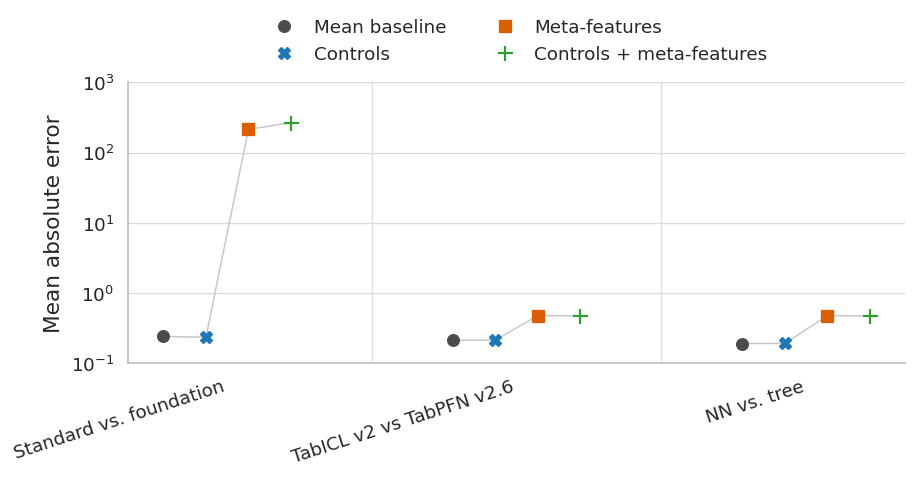

In [ ]:
comparison_order = [spec["label"] for spec in MAIN_COMPARISONS]
predictor_order = [PREDICTOR_LABELS[p] for p in PREDICTOR_SETS]
palette = {
    "Mean baseline": "#4c4c4c",
    "Controls": "#1f77b4",
    "Meta-features": "#d95f02",
    "Controls + meta-features": "#2ca02c",
}
mae_marker_styles = {
    "Mean baseline": {"marker": "o", "markersize": 7.0, "linestyle": "none"},
    "Controls": {"marker": "X", "markersize": 7.0, "linestyle": "none"},
    "Meta-features": {"marker": "s", "markersize": 6.8, "linestyle": "none"},
    "Controls + meta-features": {"marker": "+", "markersize": 9.0, "linestyle": "none"},
}


def output_paths(estimator_name: str, metric: str) -> list[Path]:
    if metric not in {"mae", "sign_accuracy"}:
        raise ValueError(metric)
    stem = "predictive_mae_main" if metric == "mae" else "predictive_sign_accuracy_main"
    stems = []
    if (
        estimator_name == "ridge"
        and ANALYSIS_TABLE == "analysis_general_reduced"
        and WRITE_PAPER_FILENAMES_FOR_RIDGE
    ):
        stems.append(stem)
    stems.append(f"{stem}_{estimator_name}")
    return list(
        dict.fromkeys(
            paper_figure_dir / f"{stem}.{fmt}"
            for stem in stems
            for fmt in EXPORT_FORMATS
        )
    )


def plot_metric(estimator_name: str, metric: str) -> tuple[plt.Figure, plt.Axes]:
    if metric == "mae":
        value_col = "mae"
        ylabel = "Mean absolute error"
    elif metric == "sign_accuracy":
        value_col = "sign_accuracy"
        ci_low_col = "sign_accuracy_ci_low"
        ci_high_col = "sign_accuracy_ci_high"
        ylabel = "Sign accuracy"
    else:
        raise ValueError(metric)

    data = summary.loc[summary["estimator"].eq(estimator_name)].copy()
    data["comparison"] = pd.Categorical(
        data["comparison"], comparison_order, ordered=True
    )
    data["predictor_label"] = pd.Categorical(
        data["predictor_label"], predictor_order, ordered=True
    )

    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    x_positions = np.arange(len(comparison_order), dtype=float)
    offsets = np.linspace(-0.22, 0.22, len(predictor_order))
    handles = []

    if metric == "mae":
        for comparison_idx, comparison in enumerate(comparison_order):
            category = (
                data.loc[data["comparison"].eq(comparison)]
                .set_index("predictor_label")
                .reindex(predictor_order)
            )
            ax.plot(
                x_positions[comparison_idx] + offsets,
                category[value_col].to_numpy(dtype=float),
                color="0.78",
                linewidth=0.9,
                zorder=1,
            )

    for predictor_label, offset in zip(predictor_order, offsets, strict=True):
        subset = (
            data.loc[data["predictor_label"].eq(predictor_label)]
            .set_index("comparison")
            .reindex(comparison_order)
            .reset_index()
        )
        xs = x_positions + offset
        ys = subset[value_col].to_numpy(dtype=float)
        color = palette[predictor_label]
        if metric == "mae":
            marker_style = mae_marker_styles[predictor_label]
            handle = ax.plot(
                xs,
                ys,
                color=color,
                markeredgecolor=color,
                markerfacecolor=color,
                markeredgewidth=(
                    1.3 if predictor_label == "Controls + meta-features" else 0.8
                ),
                label=predictor_label,
                zorder=3,
                **marker_style,
            )[0]
        else:
            ci_low = subset[ci_low_col].to_numpy(dtype=float)
            ci_high = subset[ci_high_col].to_numpy(dtype=float)
            yerr = np.vstack(
                [np.maximum(ys - ci_low, 0.0), np.maximum(ci_high - ys, 0.0)]
            )
            handle = ax.errorbar(
                xs,
                ys,
                yerr=yerr,
                fmt="o",
                markersize=5.0,
                capsize=3.0,
                elinewidth=1.1,
                markeredgewidth=0.6,
                markeredgecolor="white",
                color=color,
                label=predictor_label,
                zorder=3,
            )
        handles.append(handle)

        if metric == "sign_accuracy":
            raw = predictions.loc[
                predictions["estimator"].eq(estimator_name)
                & predictions["predictor_label"].eq(predictor_label)
            ].copy()
            for comparison_idx, comparison in enumerate(comparison_order):
                raw_group = (
                    raw.loc[
                        raw["comparison"].eq(comparison), ["dataset", "sign_correct"]
                    ]
                    .dropna(subset=["sign_correct"])
                    .sort_values("dataset")
                )
                if len(raw_group) == 0:
                    continue
                point_offsets = (
                    np.linspace(-0.045, 0.045, len(raw_group))
                    if len(raw_group) > 1
                    else np.array([0.0])
                )
                ax.plot(
                    np.full(len(raw_group), x_positions[comparison_idx] + offset)
                    + point_offsets,
                    raw_group["sign_correct"].to_numpy(dtype=float),
                    linestyle="none",
                    marker="_",
                    markersize=4.0,
                    markeredgewidth=0.8,
                    alpha=0.28,
                    color=color,
                    zorder=2,
                )

    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.set_axisbelow(True)
    ax.grid(axis="y", which="major", color="0.86", linewidth=0.8)
    ax.grid(axis="y", which="minor", visible=False)
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("0.72")
    ax.spines["bottom"].set_color("0.72")
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(comparison_order, rotation=18, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.tick_params(axis="both", labelsize=11, color="0.72")

    if metric == "mae":
        ax.set_yscale("log")
        ax.set_yticks([1e-1, 1e0, 1e1, 1e2, 1e3])
        ax.set_yticklabels(
            [r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
        )
        for separator in x_positions[:-1] + 0.5:
            ax.axvline(separator, color="0.88", linewidth=0.8, zorder=0)
    else:
        ax.set_ylim(-0.03, 1.03)
        ax.set_yticks(np.linspace(0.0, 1.0, 6))
        # ax.axhline(0.5, color="0.55", linestyle="--", linewidth=0.8, zorder=1)

    legend_handles = handles if metric == "mae" else [h.lines[0] for h in handles]
    ax.legend(
        handles=legend_handles,
        labels=predictor_order,
        ncol=2,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.04),
        borderaxespad=0.0,
        columnspacing=2.2,
        handletextpad=0.6,
        fontsize=11,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig, ax


saved_paths = []
for estimator_name in PREDICTIVE_ESTIMATORS:
    for metric in ["mae", "sign_accuracy"]:
        fig, _ = plot_metric(estimator_name, metric)
        for path in output_paths(estimator_name, metric):
            fig.savefig(path, bbox_inches="tight")
            saved_paths.append(path)
        plt.show()

pd.DataFrame({"saved_figure": [str(p) for p in saved_paths]})

## Interpretation guardrail

Use the MAE figure as the main predictive evidence. Sign accuracy is diagnostic only: it can improve even when magnitude prediction gets worse, especially when the true gap direction is imbalanced.